In [34]:
%pip install --upgrade xgboost lightgbm imbalanced-learn
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



In [35]:
train_df=pd.read_csv('train_fraud_detection.csv')
test_df=pd.read_csv('test_fraud_detection.csv')
train_df.head()

,city_pop,amount,time_diff,tx_count_24h,location_change,device_change,distance_km,hour,day_of_week,is_weekend,anomaly_score,is_fraud
0,-0.242085,-0.233664,-0.092623,0.362564,0,0,0.504115,16,1,0,0.164830,0
1,-0.290199,-0.204049,-0.544786,-0.286348,0,0,-0.544436,20,6,1,0.153877,0
2,-0.287049,-0.112376,0.089825,0.362564,0,0,-0.012140,8,1,0,0.164189,0
3,-0.290597,-0.380479,-0.573410,-0.286348,0,0,1.104335,19,6,1,0.152886,0
4,-0.289466,0.024756,-0.299769,-1.259717,0,0,-1.066904,17,0,0,0.129291,0


In [36]:
is_fraud_counts = train_df['is_fraud'].value_counts()
print(is_fraud_counts)

is_fraud
0    1031335
1       6005
Name: count, dtype: int64


In [37]:
X_train=train_df.drop('is_fraud', axis=1)
y_train=train_df['is_fraud']    
X_test=test_df.drop('is_fraud', axis=1)
y_test=test_df['is_fraud']

In [38]:
model=xgb.XGBClassifier( random_state=42,learning_rate=0.1, n_estimators=100, max_depth=5, subsample=0.8, colsample_bytree=0.8,scale_pos_weight = (len(y_train[y_train==0]) / len(y_train[y_train==1])))
model.fit(X_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [39]:
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)


In [40]:
print("Training Classification Report:")
print(classification_report(y_train, y_train_pred))
print("Training Confusion Matrix:")
print(confusion_matrix(y_train, y_train_pred))
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))


Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98   1031335
           1       0.11      0.96      0.19      6005

    accuracy                           0.95   1037340
   macro avg       0.55      0.96      0.58   1037340
weighted avg       0.99      0.95      0.97   1037340

Training Confusion Matrix:
[[983085  48250]
 [   239   5766]]
Training Accuracy: 0.9532564058071606


In [41]:
print('Testing Classification Report:')
print(classification_report(y_test, y_test_pred))
print('Testing Confusion Matrix:')
print(confusion_matrix(y_test, y_test_pred))
print('Testing Accuracy:', accuracy_score(y_test, y_test_pred))


Testing Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98    257834
           1       0.11      0.95      0.19      1501

    accuracy                           0.95    259335
   macro avg       0.55      0.95      0.58    259335
weighted avg       0.99      0.95      0.97    259335

Testing Confusion Matrix:
[[245824  12010]
 [    78   1423]]
Testing Accuracy: 0.9533884743671314


In [49]:

y_proba = model.predict_proba(X_test)[:,1]

threshold = 0.80
y_pred_custom = (y_proba > threshold).astype(int)
print('Custom Threshold Classification Report:')
print(classification_report(y_test, y_pred_custom))
print('Custom Threshold Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_custom))

Custom Threshold Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    257834
           1       0.21      0.88      0.35      1501

    accuracy                           0.98    259335
   macro avg       0.61      0.93      0.67    259335
weighted avg       0.99      0.98      0.99    259335

Custom Threshold Confusion Matrix:
[[253028   4806]
 [   185   1316]]


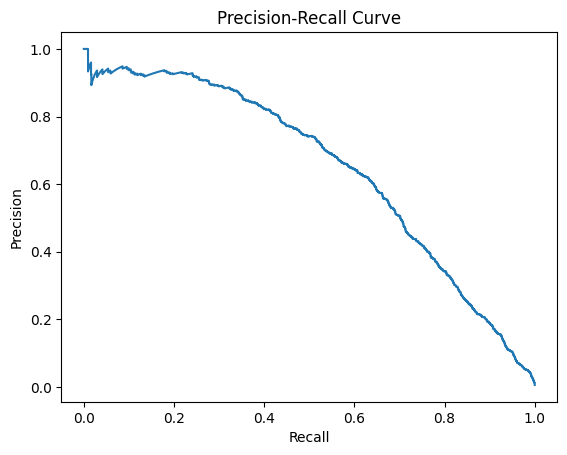

In [46]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()